# 02: Scientific Visualization
**Description:** This notebook generates the final plots for the thesis, including surface water trends and altitudinal distribution maps.
---
**Note:** Ensure your data is placed in the `../data/raw/` and `../data/processed/` folders relative to this notebook.

In [2]:
#--- IMPORT LIBRARIES --------------------


import os #so python can interact directly with computer
import matplotlib.pyplot as plt #for plotting
from matplotlib.colors import LightSource #for creating hillshade
from matplotlib.colors import ListedColormap #for coloring in plots
import matplotlib.colors as mcolors #colors
import matplotlib.patches as mpatches
from scipy.stats import linregress #compute linear regression line for statistics in plots
from scipy.stats import theilslopes #compute Theil-Sen slope for statistics in plots
import numpy as np #for arrays
import xarray as xr #for easy access to netCDF files
import pandas as pd #for tabulated data and also handles times nicely and shapefiles
import rioxarray as rxr #for multi-dimensional raster data
import rasterio #for visualizing rasters
from rasterio.mask import mask  #for clipping or masking in rasters
from rasterio.transform import array_bounds #for setting bounds
from rioxarray.merge import merge_datasets, merge_arrays #for merging rasters
import geopandas as gpd #for reading and managing vector files
import re #for lops
import cmcrameri.cm as cmc #for good colors

# Create the folder once at the start
os.makedirs('../outputs', exist_ok=True)

In [3]:
#--- Function for Adding Spatial Elements in Plots --------------------

def add_spatial_elements(ax, location='lower right'):
    # Scale Bar (drawing a line, e.g. of 5000m/5km)
    x_bar = 0.65  #position on x axis (0 to 1)
    y_bar = 0.05  #position on y-axis
    bar_length_m = 5000 #5km
    
    ax.annotate('', xy=(x_bar, y_bar), xycoords='axes fraction', 
                xytext=(x_bar + 0.1, y_bar), textcoords='axes fraction',
                arrowprops=dict(arrowstyle='-', color='black', lw=2))
    ax.text(x_bar + 0.05, y_bar + 0.02, '5 km', transform=ax.transAxes, 
            ha='center', va='bottom', fontsize=13, color='black')

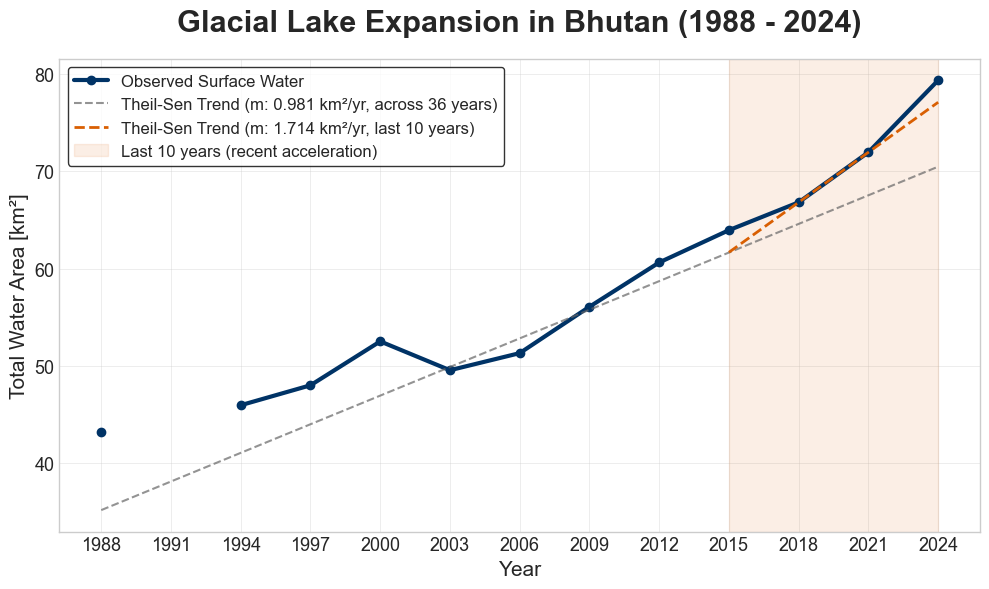

In [5]:
#--- PLOT SURFACE WATER AREA EXTENT OVER TIME PERIOD --------------------


# Load data
df = pd.read_csv('../data/processed/final_water.csv')


# Settings

# define all years
all_years = [1988, 1991, 1994, 1997, 2000, 2003, 2006, 2009, 2012, 2015, 2018, 2021, 2024]

# Reset data frame with all years
df = df.set_index('year').reindex(all_years).reset_index()
years = df['year']
counts = df['water_pixel_count']

# Exclude year 1991
counts_cleaned = counts.copy().astype(float) #make copy of counts list
counts_cleaned[years == 1991] = np.nan #index von 1991 finden und auf NaN setzen
mask = ~np.isnan(counts_cleaned)
years_corr = years[mask]
counts_corr = counts_cleaned[mask]

# Conversion factor, from pixel count to km^2
factor = 0.0009 # (30*30) / 1,000,000


# Compute Theil-Sen Trend without 1991

# Center years around first year to fix intercept
years_corr_centered = years_corr - years_corr.iloc[0]  #[0, 6, 9, 12, ...]

# Full-Trend (1988-2024)
ts_slope, ts_intercept, ts_upper, ts_lower = theilslopes(counts_corr*factor, years_corr_centered)

# Recent-Trend (2015-2024)
recent_mask = years_corr >= 2015
years_rec = years_corr[recent_mask]
years_rec_centered = years_rec - 2015  # [0, 3, 6, 9]
ts_slope_rec, ts_intercept_rec, ts_upper_rec, ts_lower_rec = theilslopes(counts_corr[recent_mask]*factor, years_rec_centered)


# Plot

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

# Water area data
ax.plot(years, counts_cleaned*factor, color='#003366', lw=3, label='Observed Surface Water', marker='o', markersize=6) #data

# Full Theil-Sen Trend (1988-2024)
ax.plot(years_corr, ts_slope * (years_corr - years_corr.iloc[0]) + ts_intercept,
        color='#666666', ls='--', lw=1.5, alpha=0.7,
        label=f'Theil-Sen Trend (m: {ts_slope:.3f} km²/yr, across 36 years)')

# Recent Theil-Sen Trend (2015-2024)
ax.plot(years_rec, ts_slope_rec * (years_rec - 2015) + ts_intercept_rec,
        color='#d95f02', ls='--', lw=2,
       label=f'Theil-Sen Trend (m: {ts_slope_rec:.3f} km²/yr, last 10 years)')

# Highlight recent area (2015-2024)
ax.axvspan(2015, 2024, color='#d95f02', alpha=0.1, label='Last 10 years (recent acceleration)')

# Layout
ax.set_title("Glacial Lake Expansion in Bhutan (1988 - 2024)", fontsize=22, fontweight='bold', pad=20)
ax.set_xlabel("Year", fontsize=15)
ax.set_ylabel("Total Water Area [km²]", fontsize=15)
ax.set_xticks(years)
ax.tick_params(axis='both', which='major', labelsize=13)
ax.grid(True, alpha=0.5, linestyle='-', linewidth=0.5) # Das Grid feiner und transparenter machen
ax.legend(frameon=True, facecolor='white', edgecolor='black', fontsize=12, loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/01_water_area.png', dpi=300, bbox_inches='tight')
plt.show()

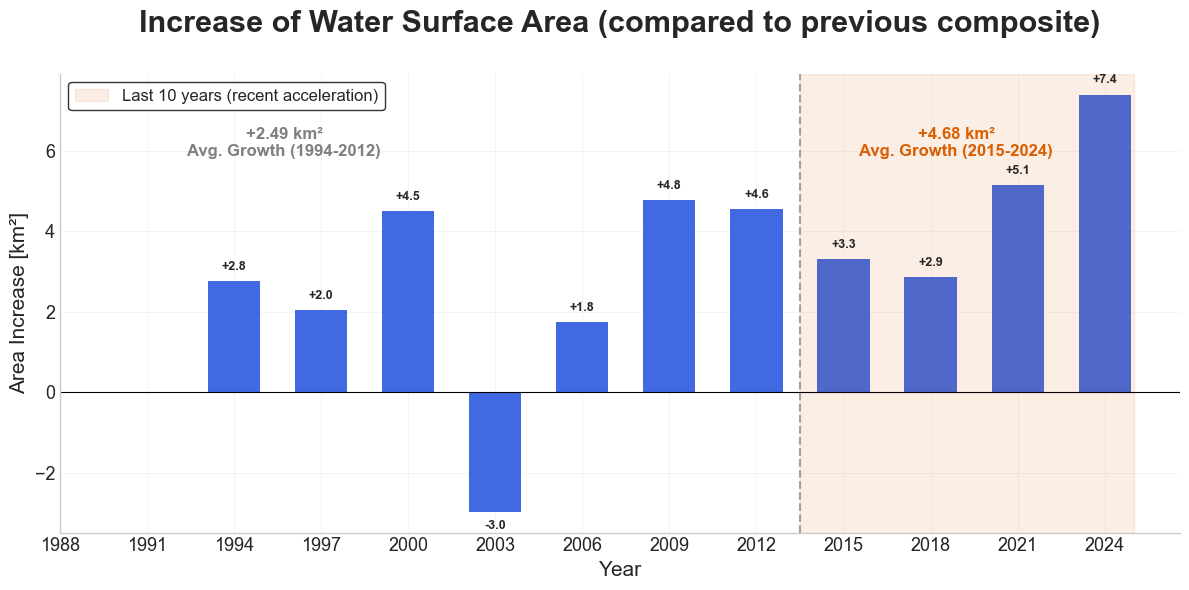

In [6]:
#--- PLOT SURFACE WATER INCREASE OVER TIME PERIOD --------------------


# Load data
df = pd.read_csv('../data/processed/final_water.csv')


# Settings

# Exclude year 1991
df = df[df['year'] != 1991]

# Conversion factor, from pixel count to km^2
df['area_km2'] = (df['water_pixel_count'] * 0.0009)

# Compute difference (Area increase by year)
df = df.sort_values('year')
df['diff_km2'] = df['area_km2'].diff()




# Plot

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 6))

# Water area increase
df_diff = df.dropna(subset=['diff_km2']) #filter NaN (for first value 1988, no comparison possible)
bars = ax.bar(df_diff['year'], df_diff['diff_km2'], color='royalblue', width=1.8)

# Compute average growth rates
avg_early = df_diff[df_diff['year'] < 2015]['diff_km2'].mean() #after 2015
avg_recent = df_diff[df_diff['year'] >= 2015]['diff_km2'].mean() #before 2015

# Highlight recent area (2015-2024)
ax.axvspan(2013.5, 2025, color='#d95f02', alpha=0.1, label='Last 10 years (recent acceleration)')

# Values above bars
for bar in bars:
    yval = bar.get_height()
    
    label = f"+{yval:.1f}" if yval > 0 else f"{yval:.1f}" #condition: if yval positive, "+" sign in front
    
    va_pos = 'bottom' if yval > 0 else 'top'  #positioning: for negative values text must be placed below bars
    offset = 0.2 if yval > 0 else -0.2
    
    ax.text(bar.get_x() + bar.get_width()/2, yval + offset, label, 
            ha='center', va=va_pos, fontsize=9, fontweight='bold')

# Text fields: average growth rates
ax.text(0.2, 0.82, f'+{avg_early:.2f} km²\nAvg. Growth (1994-2012)', 
        transform=ax.transAxes, color='grey', fontsize=12, fontweight='bold', ha='center')

ax.text(0.8, 0.82, f'+{avg_recent:.2f} km²\nAvg. Growth (2015-2024)', 
        transform=ax.transAxes, color='#d95f02', fontweight='bold', fontsize=12, ha='center')

# Layout
ax.set_title('Increase of Water Surface Area (compared to previous composite)', fontsize=22, fontweight='bold', pad=30)
ax.set_ylabel('Area Increase [km²]', fontsize=15)
ax.set_xlabel('Year', fontsize=15)
ax.set_xticks(years)
ax.tick_params(axis='both', which='major', labelsize=13) #setting fontsize for ticks, both axes
ax.axhline(0, color='black', linewidth=0.8) #zero line on x-axis for orientation
ax.axvline(x=2013.5, color='grey', linestyle='--', linewidth=1.5, alpha=0.7) #vertical line bei between 2012 and 2015
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.legend(frameon=True, facecolor='white', edgecolor='black', fontsize=12, loc='upper left')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False) #clear frame

plt.tight_layout()
plt.savefig('../outputs/02_water_increase.png', dpi=300, bbox_inches='tight')
plt.show()

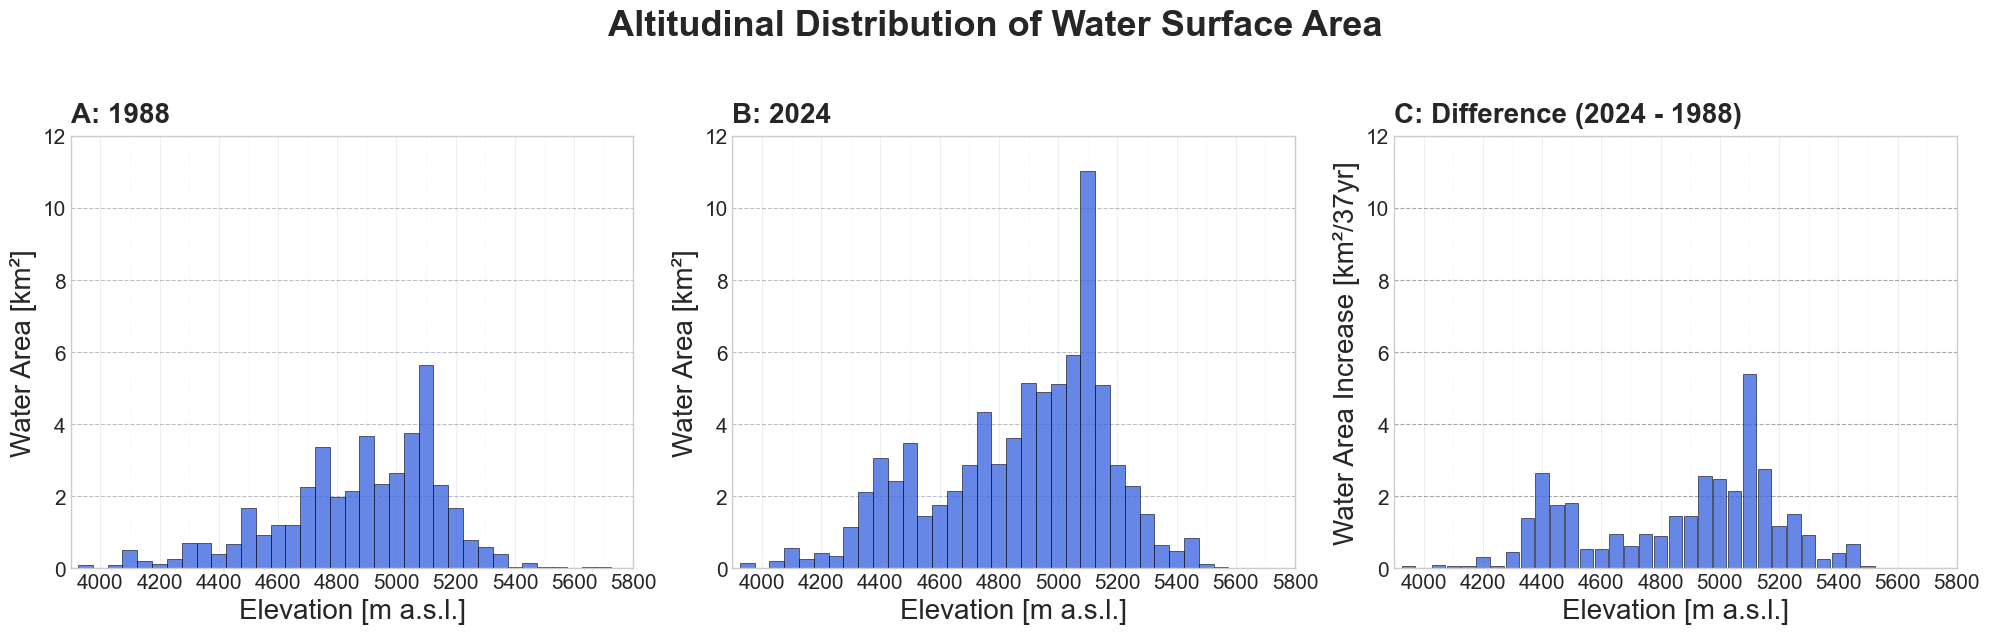

In [16]:
#--- PLOT ALTITUDINAL DISTRIBUTION OF SURFACE WATER --------------------


# Load data
df_elev = pd.read_csv('../data/processed/elevation_stats.csv')

# 2. Differenz berechnen für Plot C
df_elev['difference'] = df_elev['2024'] - df_elev['1988']

# Plot
plt.style.use('seaborn-v0_8-whitegrid') # Sauberer, wissenschaftlicher Look
#fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharex=True) #(2 Spalten, 1 Zeile)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

# Definiere die Ticks für die X-Achse (alle 200m beschriftet, alle 100m ein Strich)
major_ticks = np.arange(3800, 6100, 200)
minor_ticks = np.arange(3800, 6100, 100)

for ax in [ax1, ax2, ax3]:
    # WICHTIG: Jetzt yticks setzen, nicht xticks!
    ax.set_xticks(major_ticks)
    ax.set_xticks(minor_ticks, minor=True)
    
    # Grid anpassen
    ax.grid(which='major', linestyle='-', alpha=0.3)
    ax.grid(which='minor', linestyle=':', alpha=0.2)
    
    # Y-Achsen-Limit setzen (unser Fokus-Bereich)
    ax.set_xlim(3900, 5800)

# PLOT 1: GESAMT-PRÄSENZ (Alle Jahre summiert)
ax1.bar(df_elev['elevation_m'], df_elev['1988'],
        width=50, color='royalblue', alpha=0.8, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Elevation [m a.s.l.]', fontsize=20)
ax1.set_ylabel('Water Area [km²]', fontsize=20)
ax1.set_ylim(0, 12)
ax1.set_title('A: 1988', loc='left', fontweight='bold', fontsize=20, pad=10)
ax1.grid(axis='y', linestyle='--', alpha=0.5, color='slategrey')

# PLOT 2: NETTO-WACHSTUM (2024 vs 1988)
ax2.bar(df_elev['elevation_m'], df_elev['2024'], 
        width=50, color='royalblue', alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.set_ylabel('Water Area [km²]', fontsize=20)
ax2.set_xlabel('Elevation [m a.s.l.]', fontsize=20)
ax2.set_ylim(0, 12)
ax2.set_title('B: 2024', loc='left', fontweight='bold', fontsize=20, pad=10)
ax2.grid(axis='y', linestyle='--', alpha=0.5, color='slategrey')

# Plot C: Differenz (2024 - 1988)
# Falls du negative Werte hast, werden sie rot eingefärbt, positive blau.
colors = ['crimson' if x < 0 else 'royalblue' for x in df_elev['difference']]
ax3.bar(df_elev['elevation_m'], df_elev['difference'], 
        width=45, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax3.set_title('C: Difference (2024 - 1988)', fontsize=20, fontweight='bold', loc='left', pad=10)
ax3.set_xlabel('Elevation [m a.s.l.]', fontsize=20)
ax3.set_ylabel('Water Area Increase [km²/37yr]', fontsize=20)
ax3.set_ylim(0, 12)
ax3.grid(axis='y', linestyle='--', alpha=0.7, color='gray', linewidth=0.8)

# Zahlen-Größe anpassen
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax2.tick_params(axis='x', labelsize=15)
ax2.tick_params(axis='y', labelsize=15)
ax3.tick_params(axis='x', labelsize=15)
ax3.tick_params(axis='y', labelsize=15)
 
plt.suptitle('Altitudinal Distribution of Water Surface Area', fontsize=26, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('../outputs/03_altitude_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#--- FCC COMPILATION OF CASE STUDY --------------------


# Load data
ref_data = rxr.open_rasterio('../data/processed/NDWIg_TeilSen_Trend_PerPixel_Clean.tif') #only using for CRS
hs_raw = xr.open_dataarray('../data/processed/hillshade_xr.tif').squeeze()
folder = '../data/raw/NDWIg_138-41/'


# Settings

target_crs = ref_data.rio.crs #extract crs

# Slice to study area
hs = hs_raw.sel(x=slice(220000, 240000), y=slice(3120000, 3100000))

# Define years and time indices for ploting
time_indices = [0, 4, 8, 11] #indices of years
years = [1988, 2003, 2015, 2024]
titles = ["1988", "2003", "2015", "2024"]

# Define extent
ext = [220000, 240000, 3100000, 3120000]


# Plot

fig, axes = plt.subplots(2, 2, figsize=(16, 14), sharex=True, sharey=True)
axes = axes.flatten()

# Create proxy object for legend
nodata_patch = mpatches.Patch(
    facecolor='dimgray',     
    hatch='\\\\\\\\',     
    edgecolor='black',     
    label='No data'
)

# Loop through years
for i, idx in enumerate(time_indices):
    ax = axes[i]
    
    # Use defined year variable
    year = years[i]
    file_path = folder + f"NDWIg_138_041_y{year}.tif" #data with all bands

    # Load and reproject data
    data_raw = rxr.open_rasterio(file_path)
    data_reprojected = data_raw.rio.reproject(target_crs)
    data_study = data_reprojected.sel(x=slice(220000, 240000), y=slice(3120000, 3100000))

    # Assign band names
    band_names = ['NDWIg', 'NDWIr', 'red', 'nir', 'swir2']
    data_study = data_study.assign_coords(band=band_names)
    
    # Compute false color composite (FCC)
    fcc_data = data_study.sel(band=['swir2', 'nir', 'red'])
    
    # Scale per year for adequate contrast
    v_min, v_max = fcc_data.quantile([0.02, 0.98])
    fcc_scaled = ((fcc_data - v_min) / (v_max - v_min)).clip(0, 1)

    # Create mask where data is NaN for patch
    hole_mask = fcc_scaled.isel(band=0).isnull()
    
    # No data patch
    ax.contourf(hole_mask.x, hole_mask.y, hole_mask, levels=[0.5, 1.5], colors=['dimgray'])
    ax.contourf(hole_mask.x, hole_mask.y, hole_mask, levels=[0.5, 1.5], hatches=['\\\\\\\\'], colors='none', alpha=0)
    
    fcc_scaled.isel(band=0).notnull().astype(int).plot.contour( #fine margin line for patch
        ax=ax, levels=[0.5], colors='black', linewidths=0.4, add_colorbar=False)
    
    # Plot FCC
    fcc_scaled.plot.imshow(rgb='band', ax=ax, vmax=0.4)
    
    # Layout
    ax.set_title(titles[i], fontsize=18, fontweight='bold', pad=10)
    ax.set_aspect('equal')
    x_ticks = [225000, 235000]
    y_ticks = [3105000, 3115000]
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.legend(handles=[nodata_patch], loc='upper right', frameon=True, fontsize=12)
    ax.grid(False)
    
    # Add axes labels for outer subplots
    if i >= 2:
        ax.set_xlabel('Easting [m]', fontsize=16)
    else:
        ax.set_xlabel('')
        
    if i % 2 == 0:
        ax.set_ylabel('Northing [m]', fontsize=16)
    else:
        ax.set_ylabel('')

    add_spatial_elements(ax) 

    ax.tick_params(
        axis='both',
        which='both',
        bottom=True,
        top=False,
        left=True,
        right=False,
        labelbottom=True,
        labelleft=True,
        length=6,        
        width=1.0,      
        color='black',
        labelcolor='black'
    )
    
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(0.8)

plt.suptitle("Spatiotemporal Evolution of FCC Composites", fontsize=22, fontweight='bold', y=0.99)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('../outputs/04_fcc_compilation.png', dpi=300, bbox_inches='tight')
plt.show()

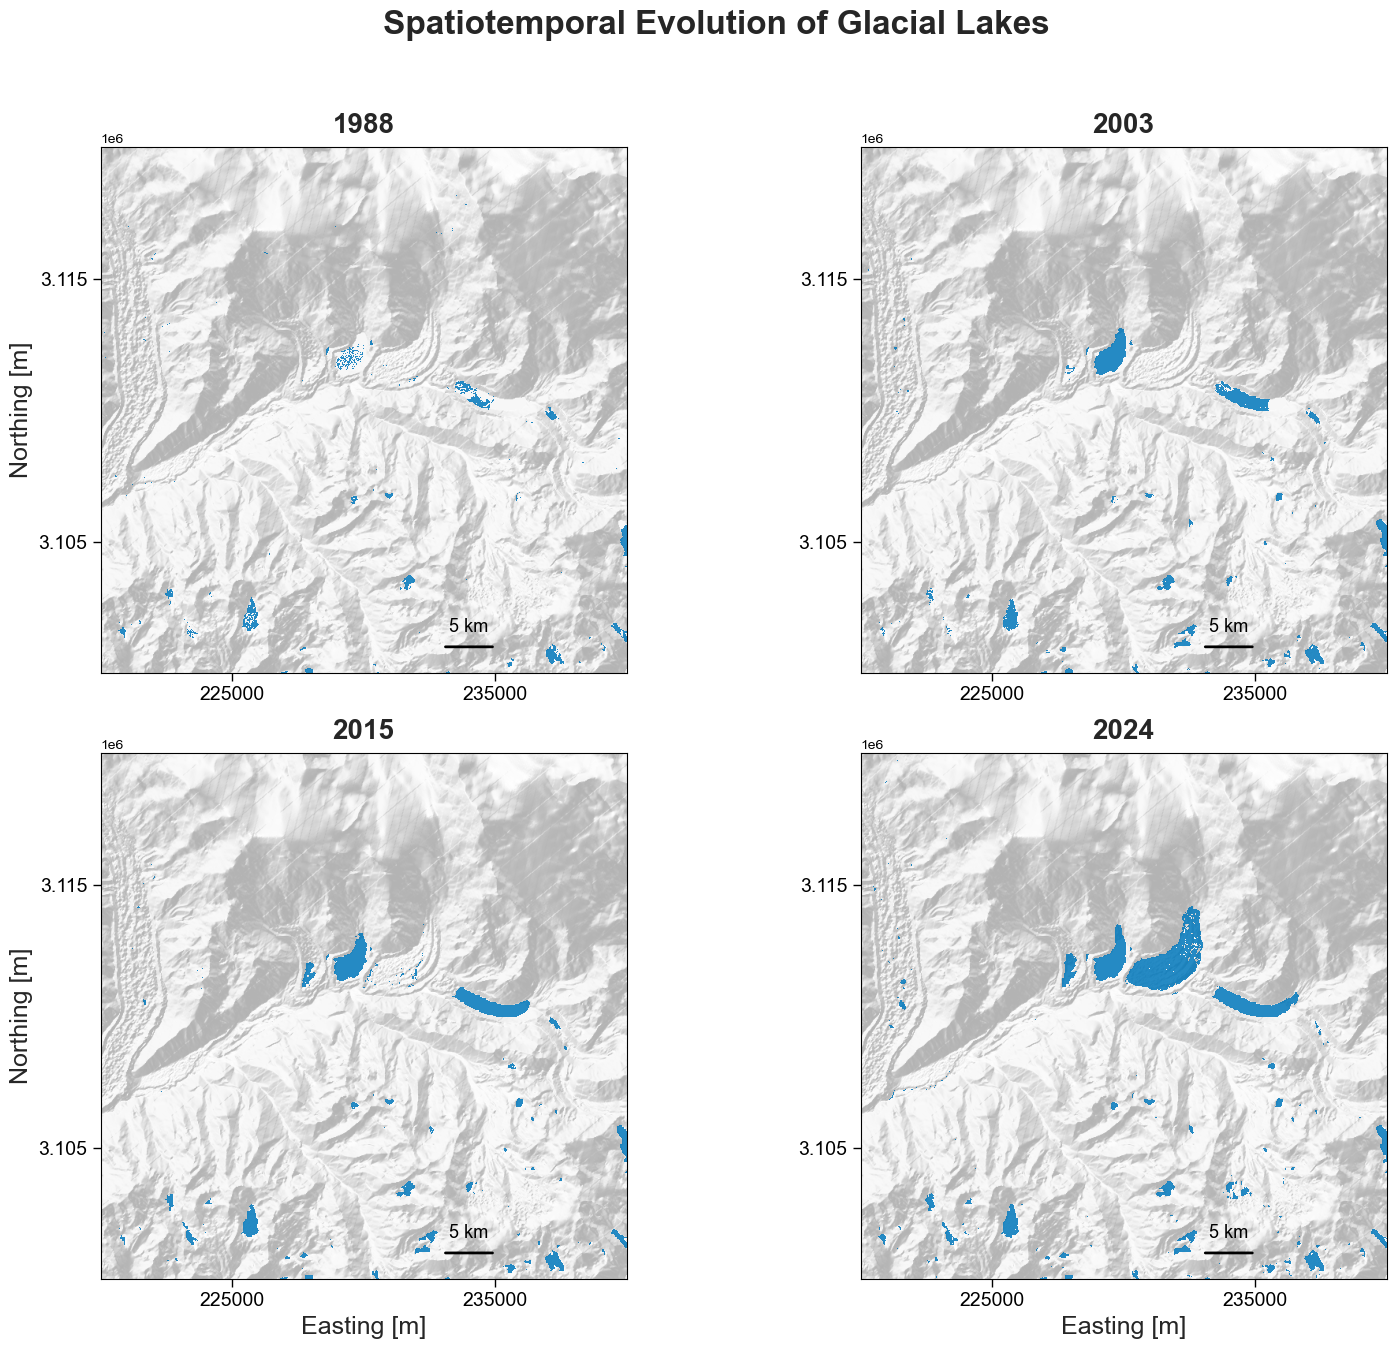

In [18]:
#--- WATERMASK COMPILATION OF CASE STUDY --------------------


# Load data
hs_raw = xr.open_dataarray('../data/processed/hillshade_xr.tif').squeeze() #Hillshade
water_stack_raw = xr.open_dataarray('../data/processed/Watermask_Timeseries_StackClean.tif').squeeze() #Watermask stack
water_stack_raw= water_stack_raw.astype('uint8')


# Settings

# Slice to study area
hs = hs_raw.sel(x=slice(220000, 240000), y=slice(3120000, 3100000))
water_stack = water_stack_raw.sel(x=slice(220000, 240000), y=slice(3120000, 3100000))

time_indices = [0, 4, 8, 11] #choose years by indices
titles = ["1988", "2003", "2015", "2024"] #name years
water_cmap = mcolors.ListedColormap(['#0077bb']) #set color


# Plot

fig, axes = plt.subplots(2, 2, figsize=(16, 14), sharex=True, sharey=True)
axes = axes.flatten() #needed

# Loop through years
for i, idx in enumerate(time_indices):
    ax = axes[i]
    
    # Hillshade
    ax.imshow(hs, cmap='Greys_r', extent=[water_stack.x.min(), water_stack.x.max(), water_stack.y.min(), water_stack.y.max()], alpha=0.3) 
    
    # Water mask
    current_water = water_stack.isel(band=idx) #only take pixel that equal 1 (water)
    
    # Apply mask: only show water pixel (1), rest of it transparent
    current_water.where(current_water == 1).plot(
        ax=ax, 
        cmap=water_cmap, 
        add_colorbar=False, 
        alpha=0.85
    )
    
    # Layout
    ax.set_title(titles[i], fontsize=20, fontweight='bold', pad=10)
    ax.set_aspect('equal')
    x_ticks = [225000, 235000]
    y_ticks = [3105000, 3115000]
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    ax.tick_params(axis='both', which='major', labelsize=14)

    # labels only on outer frames
    if i >= 2:
        ax.set_xlabel('Easting [m]', fontsize=18)
    else:
        ax.set_xlabel('')
        
    if i % 2 == 0:
        ax.set_ylabel('Northing [m]', fontsize=18)
    else:
        ax.set_ylabel('')

    add_spatial_elements(ax) 

    # small axes ticks
    ax.tick_params(
    axis='both',
    which='both',
    bottom=True,
    top=False,
    left=True,
    right=False,
    labelbottom=True,
    labelleft=True,
    length=6,       
    width=1.0,      
    color='black',
    labelcolor='black')

    for spine in ax.spines.values(): #set frame black
        spine.set_color('black')
        spine.set_linewidth(0.8)
 

plt.suptitle("Spatiotemporal Evolution of Glacial Lakes", fontsize=24, fontweight='bold', y=0.99)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('../outputs/05_watermask_compilation.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/h_/k58xsrv159qcrvq1wkttmdpr0000gq/T/ipykernel_32773/3626139440.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


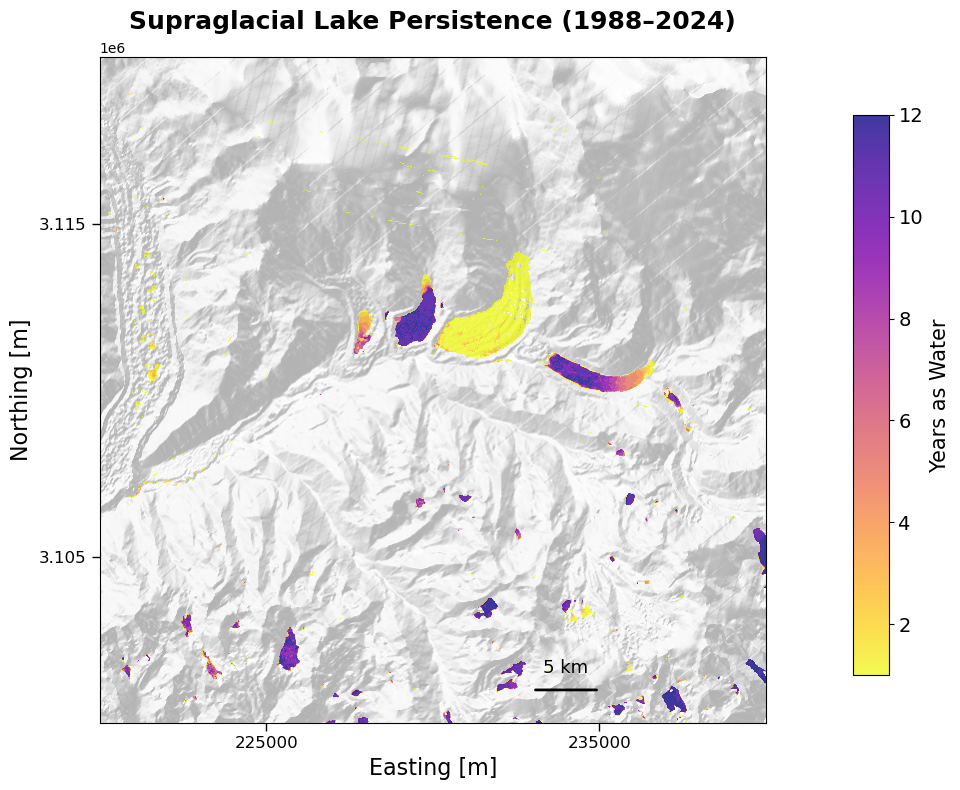

In [5]:
#--- PLOT WATER FREQUENCY ON HILLSHADE --------------------


# Load data
hs_raw = xr.open_dataarray('../data/processed/hillshade_xr.tif').squeeze()
freq_raw = xr.open_dataarray('../data/processed/Watermask_Sum_StackClean.tif').squeeze()
freq_raw= freq_raw.astype('uint8')


# Settings

# Slice to study area
hs = hs_raw.sel(x=slice(220000, 240000), y=slice(3120000, 3100000))
freq = freq_raw.sel(x=slice(220000, 240000), y=slice(3120000, 3100000))

# Apply mask to remove land
freq_masked = freq.where(freq > 0)

# Plot

fig, ax = plt.subplots(figsize=(12, 8))

# Hillshade
ax.imshow(hs, cmap='Greys_r', extent=[freq.x.min(), freq.x.max(), freq.y.min(), freq.y.max()], alpha=0.3)

# Water frequency
im = freq_masked.plot(
    ax=ax, 
    cmap='plasma_r', 
    alpha=0.8, 
    add_colorbar=False
)

# Layout
ax.set_title("Supraglacial Lake Persistence (1988–2024)", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Easting [m]', fontsize=16)
ax.set_ylabel('Northing [m]', fontsize=16)
ax.set_aspect('equal')
x_ticks = [225000, 235000]
y_ticks = [3105000, 3115000]
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.tick_params(axis='both', which='major', labelsize=12)
cbar_ax = fig.add_axes([0.85, 0.15, 0.03, 0.7]) #define position of colorbar
cbar = fig.colorbar(im, cax=cbar_ax) #create customized colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Years as Water', fontsize=15, labelpad=5) #add colorbar label
cbar.ax.spines['outline'].set_color('black')
cbar.ax.spines['outline'].set_linewidth(0.8)
for spine in ax.spines.values(): #set frame black
    spine.set_color('black')
    spine.set_linewidth(0.8)

add_spatial_elements(ax)

# small axes ticks
ax.tick_params(
    axis='both',
    which='both',
    bottom=True,
    top=False,
    left=True,
    right=False,
    labelbottom=True,
    labelleft=True,
    length=6,       
    width=1.0,      
    color='black',
    labelcolor='black'
)

plt.tight_layout()
plt.savefig('../outputs/06_water_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/h_/k58xsrv159qcrvq1wkttmdpr0000gq/T/ipykernel_32773/3849167210.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


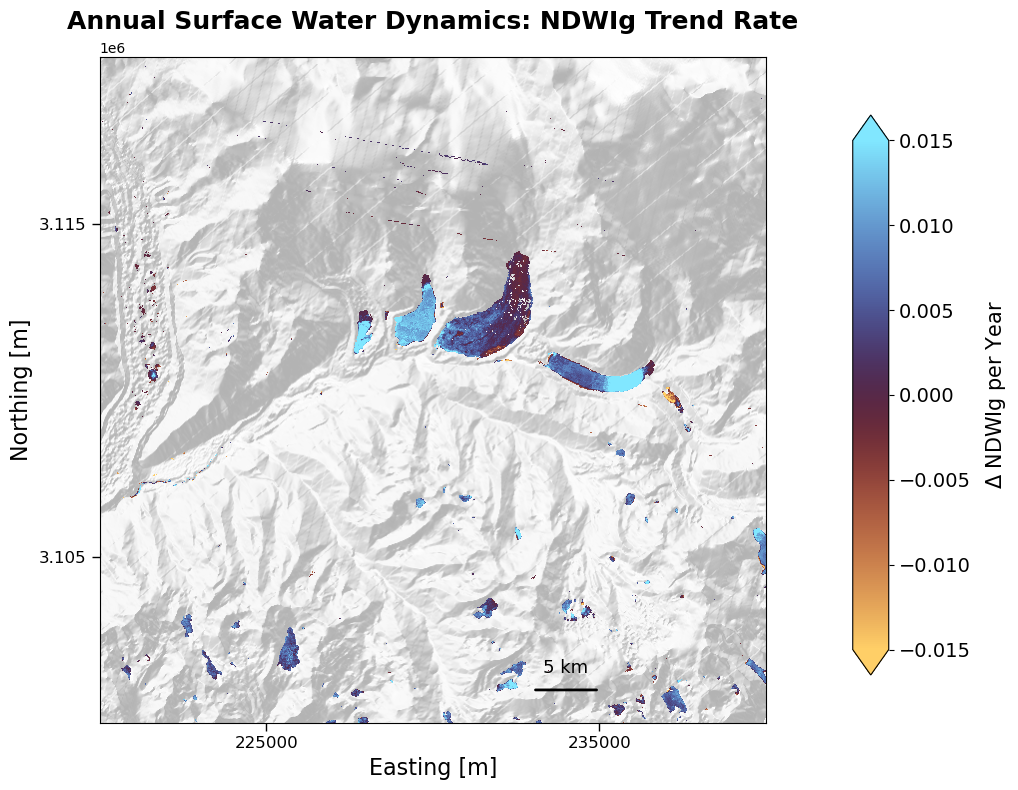

In [6]:
#--- PLOT YEARLY THEIL SEN TREND ON HILLSHADE --------------------


# Load data
hs_raw = xr.open_dataarray('../data/processed/hillshade_xr.tif').squeeze()
ndwi_trend = xr.open_dataarray('../data/processed/NDWIg_TeilSen_Trend_PerPixel_Clean.tif')
freq = xr.open_dataarray('../data/processed/Watermask_Sum_StackClean.tif').squeeze()


# Settings

# Apply mask to remove land
ndwi_clean = ndwi_trend.where(freq > 0) #use frequency map, so only areas with permanent water

# Slice to study area
hs = hs_raw.sel(x=slice(220000, 240000), y=slice(3120000, 3100000))
ndwi_clean = ndwi_clean.sel(x=slice(220000, 240000), y=slice(3120000, 3100000))


# Plot

fig, ax = plt.subplots(figsize=(12, 8))

# Hillshade
ax.imshow(hs, cmap='Greys_r', extent=[ndwi_clean.x.min(), ndwi_clean.x.max(), ndwi_clean.y.min(), ndwi_clean.y.max()], alpha=0.3) #braucht alpha=0.7 schon

# NDWI trend
im = ndwi_clean.plot(
    ax=ax, 
    cmap=cmc.managua, 
    vmin=-0.015, vmax=0.015,
    add_colorbar=False,
)

# Layout
ax.set_title("Annual Surface Water Dynamics: NDWIg Trend Rate", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Easting [m]', fontsize=16)
ax.set_ylabel('Northing [m]', fontsize=16)
ax.set_aspect('equal')
x_ticks = [225000, 235000]
y_ticks = [3105000, 3115000]
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.tick_params(axis='both', which='major', labelsize=12)
cbar_ax = fig.add_axes([0.85, 0.15, 0.03, 0.7]) #define position of colorbar
cbar = fig.colorbar(im, cax=cbar_ax, extend='both') #create customized colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label(r'$\Delta$ NDWIg per Year', fontsize=15, labelpad=10) #add colorbar label
cbar.ax.spines['outline'].set_color('black')
cbar.ax.spines['outline'].set_linewidth(0.8)
for spine in ax.spines.values(): #set frame black
    spine.set_color('black')
    spine.set_linewidth(0.8)

add_spatial_elements(ax)

# small axes ticks
ax.tick_params(
    axis='both',
    which='both',
    bottom=True,
    top=False,
    left=True,
    right=False,
    labelbottom=True,
    labelleft=True,
    length=6,       
    width=1.0,      
    color='black',
    labelcolor='black'
)

plt.tight_layout()
plt.savefig('../outputs/07_annual_theilsen.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/h_/k58xsrv159qcrvq1wkttmdpr0000gq/T/ipykernel_32773/1653567578.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


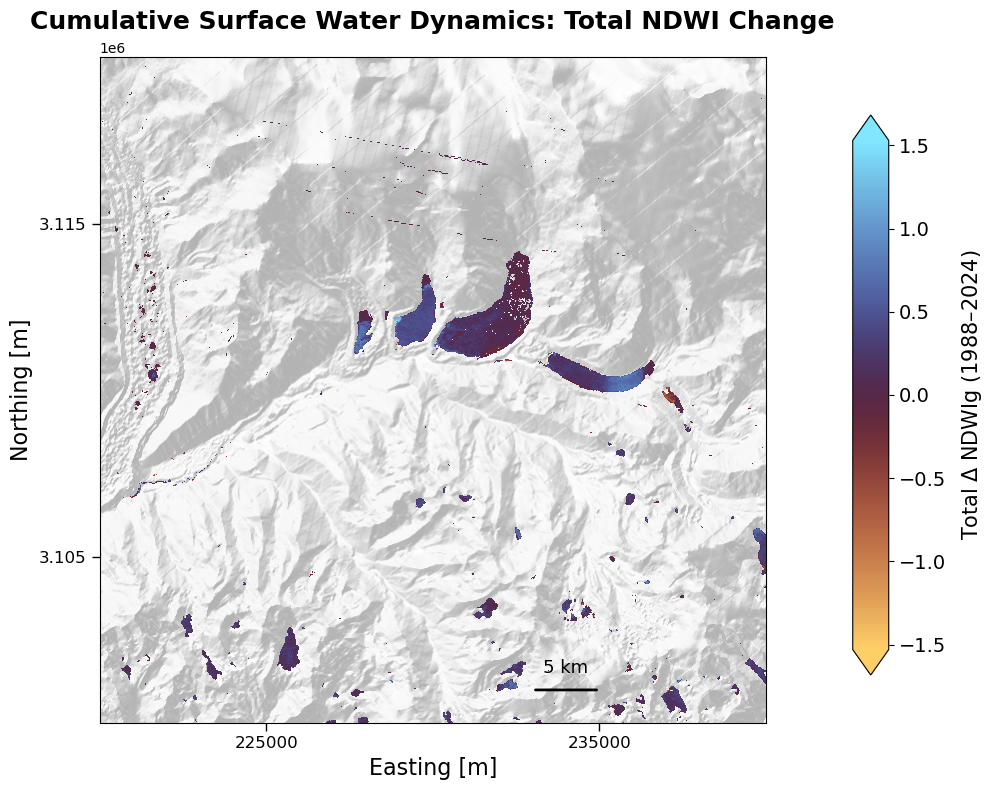

In [7]:
#--- PLOT TOTAL THEIL SEN TREND ON HILLSHADE --------------------


# Load data
hs_raw = xr.open_dataarray('../data/processed/hillshade_xr.tif').squeeze()
ndwi_trend = xr.open_dataarray('../data/processed/NDWIg_TeilSen_Trend_PerPixel_Clean.tif')
freq = xr.open_dataarray('../data/processed/Watermask_Sum_StackClean.tif').squeeze()


# Settings

# Calculate total NDWI change
total_ndwi_change = ndwi_trend * (2024 - 1988)

# Apply mask to remove land
total_change_masked = total_ndwi_change.where(freq > 0) #use frequency map, so only areas with permanent water

# Slice to study area
final = total_change_masked.sel(x=slice(220000, 240000), y=slice(3120000, 3100000))
hs_final = hs_raw.sel(x=slice(220000, 240000), y=slice(3120000, 3100000))


# Plot

fig, ax = plt.subplots(figsize=(12, 8))

# Hillshade
ax.imshow(hs_final, cmap='Greys_r', extent=[final.x.min(), final.x.max(), final.y.min(), final.y.max()], alpha=0.3)

# NDWI trend
im = final.plot(
    ax=ax,
    cmap=cmc.managua,        
    #vmin=-v_limit, 
    #vmax=v_limit,
    add_colorbar=False
)

# Layout
ax.set_title("Cumulative Surface Water Dynamics: Total NDWI Change", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Easting [m]', fontsize=16)
ax.set_ylabel('Northing [m]', fontsize=16)
ax.set_aspect('equal')
x_ticks = [225000, 235000]
y_ticks = [3105000, 3115000]
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.tick_params(axis='both', which='major', labelsize=12)
cbar_ax = fig.add_axes([0.85, 0.15, 0.03, 0.7]) #define position of colorbar
cbar = fig.colorbar(im, cax=cbar_ax, extend='both') #create customized colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label(r'Total $\Delta$ NDWIg (1988–2024)', fontsize=15, labelpad=10) #add colorbar label
cbar.ax.spines['outline'].set_color('black')
cbar.ax.spines['outline'].set_linewidth(0.8)
for spine in ax.spines.values(): #set frame black
    spine.set_color('black')
    spine.set_linewidth(0.8)

add_spatial_elements(ax)

# small axes ticks
ax.tick_params(
    axis='both',
    which='both',
    bottom=True,
    top=False,
    left=True,
    right=False,
    labelbottom=True,
    labelleft=True,
    length=6,       
    width=1.0,      
    color='black',
    labelcolor='black'
)

plt.tight_layout()
plt.savefig('../outputs/08_total_theilsen.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/h_/k58xsrv159qcrvq1wkttmdpr0000gq/T/ipykernel_32773/1770557320.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


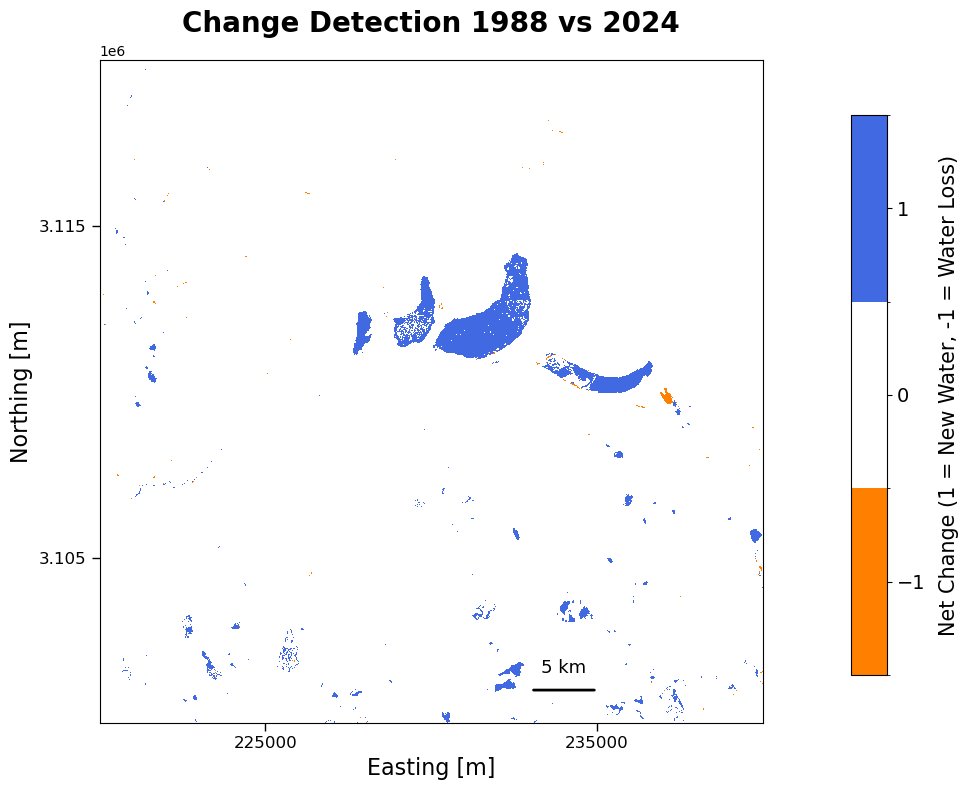

In [9]:
#--- PLOT NET CHANGE ON HILLSHADE --------------------

# Load data
mask_1988 = xr.open_dataarray('../data/processed/Full_Masks/bhutan_full_mask_1988.tif') #1988 water mask
mask_2024 = xr.open_dataarray('../data/processed/Full_Masks/bhutan_full_mask_2024.tif') #2024 water mask
hs_raw = xr.open_dataarray('../data/processed/hillshade_xr.tif').squeeze()


# Settings

# Slice to study area
hs = hs_raw.sel(x=slice(220000, 240000), y=slice(3120000, 3100000))
mask_1988 = mask_1988.sel(x=slice(220000, 240000), y=slice(3120000, 3100000))
mask_2024 = mask_2024.sel(x=slice(220000, 240000), y=slice(3120000, 3100000))

# Calculate difference
change = mask_2024.astype(float) - mask_1988.astype(float) #1 = New Water (was 0, now 1), 0 = No change, -1 = Water loss (was 1, now 0)

# Set colormap
color_loss = '#ff7f00'   
color_none = '#ffffff'   
color_gain = 'royalblue'
my_cmap = mcolors.ListedColormap([color_loss, color_none, color_gain])


# Plot

fig, ax = plt.subplots(figsize=(12, 8))

# Hillshade
ax.imshow(hs, cmap='Greys_r', extent=[ndwi_clean.x.min(), ndwi_clean.x.max(), ndwi_clean.y.min(), ndwi_clean.y.max()], alpha=0.3)

# Change of water presence
im = change.plot(
    ax=ax, 
    cmap=my_cmap, 
    center=0, 
    levels=[-1.5, -0.5, 0.5, 1.5], 
    add_colorbar=False) #suppress default colorbar

# Layout
ax.set_title(f"Change Detection 1988 vs 2024", fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Easting [m]', fontsize=16)
ax.set_ylabel('Northing [m]', fontsize=16)
ax.set_aspect('equal', adjustable='box')
x_ticks = [225000, 235000]
y_ticks = [3105000, 3115000]
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.tick_params(axis='both', which='major', labelsize=12)
cbar_ax = fig.add_axes([0.85, 0.15, 0.03, 0.7]) #define position of colorbar
cbar = fig.colorbar(im, cax=cbar_ax) #create customized colorbar
cbar.set_ticks([-1, 0, 1]) #set ticks to exactly -1, 0, and 1
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Net Change (1 = New Water, -1 = Water Loss)", fontsize=15, labelpad=10) #add colorbar label
cbar.ax.spines['outline'].set_color('black')
cbar.ax.spines['outline'].set_linewidth(0.8)
for spine in ax.spines.values(): #set frame black
    spine.set_color('black')
    spine.set_linewidth(0.8)

add_spatial_elements(ax)

# small axes ticks
ax.tick_params(
    axis='both',
    which='both',
    bottom=True,
    top=False,
    left=True,
    right=False,
    labelbottom=True,
    labelleft=True,
    length=6,       
    width=1.0,      
    color='black',
    labelcolor='black'
)

plt.tight_layout()
plt.savefig('../outputs/09_net_change.png', dpi=300, bbox_inches='tight')
plt.show()